# 🌿 CropGuard: A Data Mining Approach for Crop Disease Detection
### PlantVillage Dataset — Exploratory Data Analysis
---
**Project Type:** Data Mining Project

**Dataset:** PlantVillage (54,305 images — 38 disease classes)  
**Source:** Kaggle — emmarex/plantdisease

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial.distance import euclidean
import kagglehub

print("All libraries imported successfully!")

All libraries imported successfully!


C:\Users\nadaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2 — Download & Load the Dataset
Downloads PlantVillage automatically from Kaggle, then reads all images and extracts color features (R, G, B channels + brightness) into a DataFrame.

In [2]:
# Download PlantVillage dataset automatically from Kaggle
path = kagglehub.dataset_download("emmarex/plantdisease")
print("Path to dataset files:", path)

# The dataset folder is inside the downloaded path
DATASET_PATH = os.path.join(path, "PlantVillage")

# Walk through all folders and collect image info
rows = []

for class_folder in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_folder)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.JPG', '.png'))]

        for img_file in images:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img_resized = img.resize((64, 64))          # resize to 64x64
                arr = np.array(img_resized).astype(float)   # convert to array

                rows.append({
                    "filename":   img_file,
                    "class":      class_folder,
                    "mean_R":     arr[:, :, 0].mean(),      # average Red channel
                    "mean_G":     arr[:, :, 1].mean(),      # average Green channel
                    "mean_B":     arr[:, :, 2].mean(),      # average Blue channel
                    "std_R":      arr[:, :, 0].std(),
                    "std_G":      arr[:, :, 1].std(),
                    "std_B":      arr[:, :, 2].std(),
                    "brightness": arr.mean(),               # overall brightness
                })
            except Exception:
                pass   # skip corrupted images

df = pd.DataFrame(rows)
print("Dataset loaded successfully!")
print(f"Total images: {len(df)}")

100%|██████████| 658M/658M [04:22<00:00, 2.63MB/s] 

Extracting files...


Path to dataset files: C:\Users\nadaa\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1
Dataset loaded successfully!
Total images: 20637


## Step 3 — Basic Statistics


In [3]:
print("=== Dataset Shape ===")
print(df.shape)
print()

=== Dataset Shape ===
(20637, 9)



In [4]:
print("=== Basic Statistics ===")
df.describe()

=== Basic Statistics ===


,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
count,20637.000000,20637.000000,20637.000000,20637.000000,20637.000000,20637.000000,20637.000000
mean,116.995314,121.134715,104.885409,40.942615,34.580344,45.658992,114.338479
std,18.018836,17.275797,17.466852,10.814695,9.553163,10.066819,16.420443
min,8.347412,8.712158,5.743164,8.739276,7.350812,10.828948,7.694010
25%,106.785156,110.942139,94.241699,34.243213,27.648597,39.947810,104.949870
50%,117.507324,120.572754,105.890381,41.679146,33.955474,45.838376,114.423340
75%,127.262939,130.220703,115.846680,48.106294,40.785995,52.345603,123.444092
max,194.232178,201.574219,188.663574,92.583412,89.111749,84.591304,192.921224


In [5]:
print("=== First 20 Rows ===")
df.head(20)

=== First 20 Rows ===


,filename,class,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
0,0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Sp...,Pepper__bell___Bacterial_spot,124.468262,125.633789,108.484375,47.275037,37.722752,50.531852,119.528809
1,006adb74-934f-448f-a14f-62181742127b___JR_B.Sp...,Pepper__bell___Bacterial_spot,99.804443,106.239014,95.649414,47.852956,40.071844,51.767020,100.564290
2,00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Sp...,Pepper__bell___Bacterial_spot,128.867920,133.111816,125.541504,47.887144,38.783827,52.471860,129.173747
3,01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Sp...,Pepper__bell___Bacterial_spot,118.653076,129.784424,97.639160,41.599596,36.581054,48.372801,115.358887
4,0169b9ac-07b9-4be1-8b85-da94481f05a4___NREC_B....,Pepper__bell___Bacterial_spot,94.515625,103.369873,79.208252,54.417106,46.537558,55.417854,92.364583
5,018e494e-d2eb-468b-9d02-40219d9f4921___JR_B.Sp...,Pepper__bell___Bacterial_spot,110.710938,120.166016,93.424805,45.507967,26.466790,46.458401,108.100586
6,01940b6d-7dea-4889-a7b8-a35f4e9bba34___NREC_B....,Pepper__bell___Bacterial_spot,104.103271,111.845703,90.529785,55.170623,52.461343,54.977491,102.159587
7,01dfb88b-cd5a-420c-b163-51f5fe07b74d___JR_B.Sp...,Pepper__bell___Bacterial_spot,135.247559,131.896729,94.366211,40.565633,33.151004,51.077952,120.503499
8,01ebc916-4793-40a3-b5e4-a32687e4fa3d___NREC_B....,Pepper__bell___Bacterial_spot,101.136963,108.727051,88.016113,55.281038,46.191667,57.320135,99.293376
9,024623ab-be81-4d99-a653-c3be1495ce8e___JR_B.Sp...,Pepper__bell___Bacterial_spot,115.937256,124.022705,105.479736,58.215699,42.888655,59.488277,115.146566


## Step 4 — Detect Missing Values

In [6]:
print("=== Missing Values Per Column ===")
print(df.isnull().sum())

=== Missing Values Per Column ===
filename      0
class         0
mean_R        0
mean_G        0
mean_B        0
std_R         0
std_G         0
std_B         0
brightness    0
dtype: int64


In [7]:
print("=== Missing Values Map (True = missing) ===")
df.isnull()

=== Missing Values Map (True = missing) ===


,filename,class,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20632,False,False,False,False,False,False,False,False,False
20633,False,False,False,False,False,False,False,False,False
20634,False,False,False,False,False,False,False,False,False
20635,False,False,False,False,False,False,False,False,False


## Step 5 — Handle Missing Values


In [8]:
df_clean = df.dropna()

# Fill remaining missing values with median (safer for image features)
df = df.fillna(df.median(numeric_only=True))

print("=== After Handling Missing Values ===")
print(df.isnull().sum())

=== After Handling Missing Values ===
filename      0
class         0
mean_R        0
mean_G        0
mean_B        0
std_R         0
std_G         0
std_B         0
brightness    0
dtype: int64


## Step 6 — Class Distribution
How many images exist per disease class — like checking column values in the diabetes example.

In [9]:
print("=== Number of Images Per Disease Class ===")
class_counts = df["class"].value_counts()
print(class_counts)

=== Number of Images Per Disease Class ===
class
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1908
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato_healthy                                 1591
Pepper__bell___healthy                         1478
Tomato__Target_Spot                            1404
Potato___Early_blight                          1000
Potato___Late_blight                           1000
Tomato_Early_blight                            1000
Pepper__bell___Bacterial_spot                   997
Tomato_Leaf_Mold                                952
Tomato__Tomato_mosaic_virus                     373
Potato___healthy                                152
Name: count, dtype: int64


In [10]:
# Check if any class has less than 10 images
print("=== Classes with Less Than 10 Images ===")
print(class_counts[class_counts < 10])

=== Classes with Less Than 10 Images ===
Series([], Name: count, dtype: int64)


## Step 7 — Variance


In [11]:
print("=== Variance of Each Feature ===")
print(df[["mean_R", "mean_G", "mean_B", "brightness"]].var())

=== Variance of Each Feature ===
mean_R        324.678438
mean_G        298.453153
mean_B        305.090919
brightness    269.630944
dtype: float64


## Step 8 — Covariance Matrix


In [12]:
print("=== Covariance Matrix ===")
covar_matrix = df[["mean_R", "mean_G", "mean_B", "brightness"]].cov()
print(covar_matrix)

=== Covariance Matrix ===
                mean_R      mean_G      mean_B  brightness
mean_R      324.678438  283.731609  242.771051  283.727032
mean_G      283.731609  298.453153  222.725333  268.303365
mean_B      242.771051  222.725333  305.090919  256.862434
brightness  283.727032  268.303365  256.862434  269.630944


## Step 9 — Euclidean Distance


In [13]:
features = ["mean_R", "mean_G", "mean_B", "brightness"]

row1 = df[features].iloc[0].astype(float).values
row2 = df[features].iloc[1].astype(float).values

dist = euclidean(row1, row2)
print(f"=== Euclidean Distance Between Image 1 and Image 2 ===")
print(f"Distance: {dist:.4f}")

=== Euclidean Distance Between Image 1 and Image 2 ===
Distance: 38.8439


## Step 10 — NumPy Operations


In [14]:
brightness_array = np.array(df["brightness"])

print("=== NumPy Operations on Brightness Column ===")
print(f"Mean brightness:  {np.mean(brightness_array):.2f}")
print(f"Std  brightness:  {np.std(brightness_array):.2f}")
print(f"Min  brightness:  {np.min(brightness_array):.2f}")
print(f"Max  brightness:  {np.max(brightness_array):.2f}")
print()
print("=== Any NaN in brightness array? ===")
print(np.isnan(brightness_array).sum(), "NaN values found")

=== NumPy Operations on Brightness Column ===
Mean brightness:  114.34
Std  brightness:  16.42
Min  brightness:  7.69
Max  brightness:  192.92

=== Any NaN in brightness array? ===
0 NaN values found


## Step 11 — Visualization


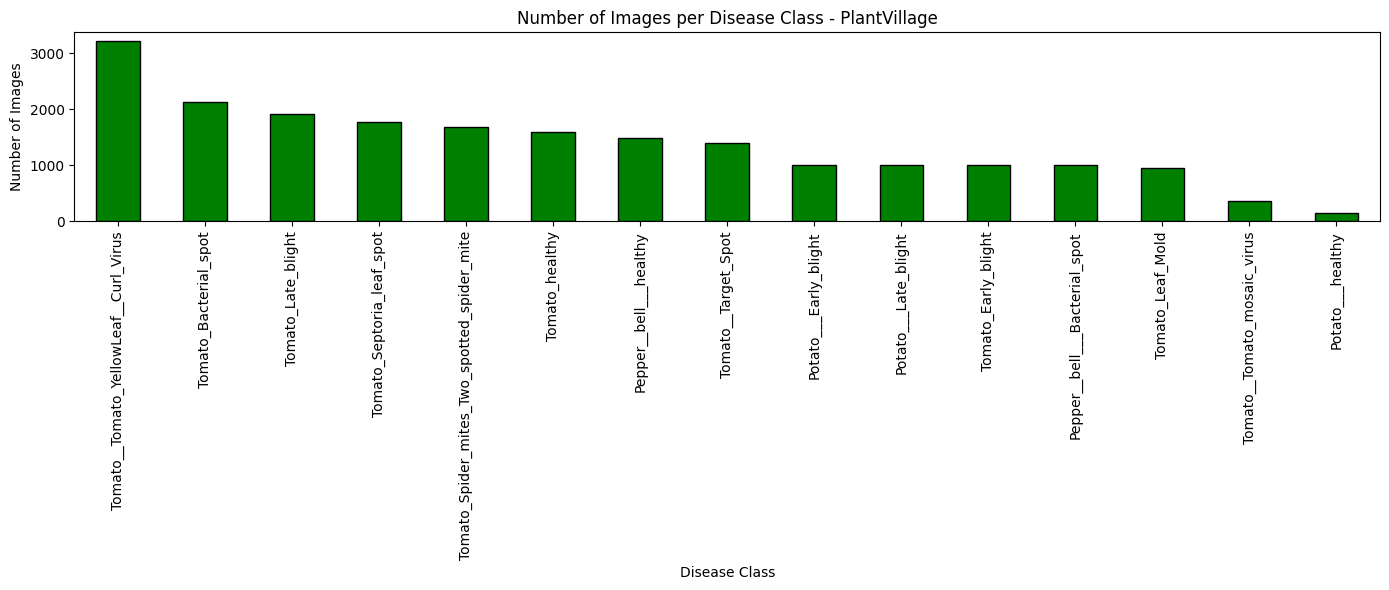

Chart saved as class_distribution.png


In [15]:
plt.figure(figsize=(14, 6))
class_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title("Number of Images per Disease Class - PlantVillage")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()
print("Chart saved as class_distribution.png")